# The J1-J2 model

The [J1-J2 model](https://en.wikipedia.org/wiki/J1_J2_model) contains both nearest-neighbor and next-to-nearest-neighbor interactions.
$$H = J_1 \sum_{\langle i, j \rangle} \vec{\sigma}_i \cdot \vec{\sigma}_j + J_2 \sum_{\langle \langle i, j \rangle \rangle} \vec{\sigma}_i \cdot \vec{\sigma}_j$$

In [33]:
from typing import Dict, List
from copy import deepcopy
import h5py
from math import sqrt
import numpy as np
import scipy as sp
import scipy.linalg as la
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import networkx as nx
import cirq
import openfermion as of
import qiskit
from quimb.tensor import DMRG
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, total_number_qubit_operator, get_evolved_states,
    fill_subspace_matrices_mps, mps_to_vector, exact_evolved_states,
    fill_subspace_matrices_vectors
)

In [25]:
def j1j2_hamiltonian(graph: nx.Graph, j1: float, j2: float) -> cirq.PauliSum:
    """Get the J1-J2 Hamiltonian."""

    qs = cirq.LineQubit.range(len(graph.nodes))
    ham = cirq.PauliSum()
    for i in graph.nodes:
        neighbors = graph.neighbors(i)
        for j in neighbors:
            sigma_dot_sigma = 1.0 * cirq.X.on(qs[i]) * cirq.X.on(qs[j]) \
                + 1.0 * cirq.Y.on(qs[i]) * cirq.Y.on(qs[j]) \
                + 1.0 * cirq.Z.on(qs[i]) * cirq.Z.on(qs[j])
            ham += 0.5 * j1 * sigma_dot_sigma
            j_neighbors = graph.neighbors(j)
            for jn in j_neighbors:
                if jn != i:
                    sigma_dot_sigma = 1.0 * cirq.X.on(qs[i]) * cirq.X.on(qs[jn]) \
                        + 1.0 * cirq.Y.on(qs[i]) * cirq.Y.on(qs[jn]) \
                        + 1.0 * cirq.Z.on(qs[i]) * cirq.Z.on(qs[jn])
                    ham += 0.5 * j2 * sigma_dot_sigma
    return ham

In [26]:
l = 6
j1 = 1.0
j2 = 2.0
mpo_bond = 100
bond_dims = [2, 4, 6, 8]
d = 20
tau = 0.1
steps = 10
eps = 1e-10

grid_graph = nx.grid_graph(dim=(l,1))
grid_graph = nx.convert_node_labels_to_integers(grid_graph)
hamiltonian = j1j2_hamiltonian(grid_graph, j1, j2)
ham_mpo = pauli_sum_to_mpo(hamiltonian, hamiltonian.qubits, mpo_bond)

In [27]:
for ps in hamiltonian:
    print(ps)

X(q(0))*X(q(1))
Y(q(0))*Y(q(1))
Z(q(0))*Z(q(1))
(2+0j)*X(q(0))*X(q(2))
(2+0j)*Y(q(0))*Y(q(2))
(2+0j)*Z(q(0))*Z(q(2))
X(q(1))*X(q(2))
Y(q(1))*Y(q(2))
Z(q(1))*Z(q(2))
(2+0j)*X(q(1))*X(q(3))
(2+0j)*Y(q(1))*Y(q(3))
(2+0j)*Z(q(1))*Z(q(3))
X(q(2))*X(q(3))
Y(q(2))*Y(q(3))
Z(q(2))*Z(q(3))
(2+0j)*X(q(2))*X(q(4))
(2+0j)*Y(q(2))*Y(q(4))
(2+0j)*Z(q(2))*Z(q(4))
X(q(3))*X(q(4))
Y(q(3))*Y(q(4))
Z(q(3))*Z(q(4))
(2+0j)*X(q(3))*X(q(5))
(2+0j)*Y(q(3))*Y(q(5))
(2+0j)*Z(q(3))*Z(q(5))
X(q(4))*X(q(5))
Y(q(4))*Y(q(5))
Z(q(4))*Z(q(5))


## Exact diagonalization

In [28]:
ham_matrix = hamiltonian.matrix()
eigvals, eigvecs = la.eigh(ham_matrix)
ground_energy = np.min(eigvals)
print(f"Exact energy: {ground_energy}")

Exact energy: -18.126337365215832


## DMRG

In [29]:
dmrg_bond_dims = [5, 7, 9]
dmrg_energies = []
dmrg_states = []
for chi_dmrg in dmrg_bond_dims:
    print(f"chi = {chi_dmrg}")
    dmrg = DMRG(ham_mpo, chi_dmrg)
    converged = dmrg.solve()
    if not converged:
        print("DMRG did not converge!")
    ground_energy = dmrg.energy.real
    print(f"Got energy {ground_energy}")
    ground_state = dmrg.state
    dmrg_states.append(ground_state.copy())
    dmrg_energies.append(ground_energy)

chi = 5
DMRG did not converge!
Got energy -17.60211313736246
chi = 7
DMRG did not converge!
Got energy -17.948677457516716
chi = 9
Got energy -18.126337365215793


## Krylov

In [30]:
ev_circuit = trotter_circuit_from_psum(hamiltonian, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit)

In [35]:
krylov_bond_dims = deepcopy(dmrg_bond_dims)
krylov_energies = np.zeros((len(bond_dims), d-1), dtype=float)
ref_state = dmrg_states[0].copy()
for i, chi in enumerate(krylov_bond_dims):
    print(f"chi = {chi}")
    states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi, None)
    h, s = fill_subspace_matrices_mps(states, ham_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    krylov_energies[i, :] = energies

chi = 5
chi = 7
chi = 9


In [36]:
krylov_errs = np.abs(krylov_energies - ground_energy)

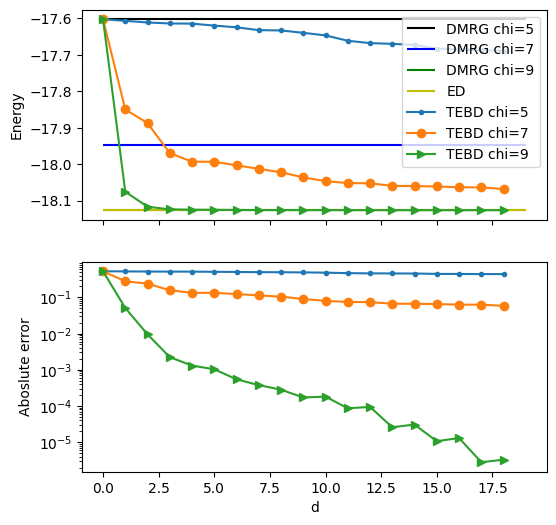

In [39]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
markers = [".", "o", ">", "P"]
colors = ["k", "b", "g", "r"]
for i, chi in enumerate(dmrg_bond_dims):
    ax[0].hlines(dmrg_energies[i], 0., krylov_energies.shape[1], colors=colors[i], label=f"DMRG chi={chi}")
ax[0].hlines(ground_energy, 0., krylov_energies.shape[1], colors="y", label="ED")
for i, chi in enumerate(krylov_bond_dims):
    ax[0].plot(krylov_energies[i, :], marker=markers[i], label=f"TEBD chi={chi}")
    ax[1].plot(krylov_errs[i, :], marker=markers[i], label=f"TEBD chi={chi}")
ax[0].legend()
ax[0].set_ylabel("Energy")
ax[1].set_ylabel("Aboslute error")
ax[1].set_xlabel("d")
ax[1].set_yscale("log")